### Mushroom (calssification) dataset
Location of dataset: https://www.kaggle.com/datasets/vishalpnaik/mushroom-classification-edible-or-poisonous/data. The goal is to predict whether a mushroom is edible or poisonous. There are 61069 rows in the dataset. Data analysis locates here: Exercise_project_1\Classification_dataset\dataset_analysis_code.ipynb
Target variable is Class (binary, classification).

#### Continuation of ANN_classification_1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [3]:
# load the data
df = pd.read_csv('mushroom_reduced.csv')

df.head() 

,stem-width,stem-color_w,gill-spacing_d,gill-attachment_p,stem-height,class
0,17.09,1,0,0,16.95,1
1,18.19,1,0,0,17.99,1
2,17.74,1,0,0,17.80,1
3,15.98,1,0,0,15.77,1
4,17.20,1,0,0,16.53,1


In [4]:
# everything else except the target variable
X = df.drop("class", axis=1)

# have only the target variable here (dependent variable)
y = df['class']



#### train/test/validation -split

In [5]:
# this time, let's split the data into 65% (training data) and 35% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.35)

# step 2, split the temporary data in HALF (0.5) => 17.5% test and 17.5% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

#### Create the neural network structure

In [6]:
# One-hot encode the target variable for categorical classification
from keras.utils import to_categorical

# Convert to one-hot encoding with 2 classes
# here I used a bit of AI
y_train_encoded = to_categorical(y_train, num_classes=2)
y_val_encoded = to_categorical(y_val, num_classes=2)
y_test_encoded = to_categorical(y_test, num_classes=2)

# Define Sequential neural network model
# modify the input shape to match your training column count
# remember, one of the columns is removed from training columns
# to be the target value. so if your data originally had 10 columns
# the input shape is 9 ... (10 - 1 => 9)
# the input layer itself can have a different number of nodes
# Tip: have at least the same number of nodes as in the input shape
# output layer in classification depends on amount of output options in target variable
model = keras.Sequential(
    [
        layers.BatchNormalization(input_shape=(len(X.columns),)),
        layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l1(l1=0.1)),
        layers.Dense(8, activation="relu"),
        layers.Dense(2, activation="softmax")  # Output layer: 2 nodes for binary classification
    ]
)

# compile the model, this time we use categorical crossentropy for loss -function
# and we also measure the accuracy of our model in the metrics
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Storage\Studies\Lapland_AMK\5_semester\Deep_learning\.venv312\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270 (1.05 KB)

 Trainable params: 260 (1.02 KB)

 Non-trainable params: 10 (40.00 B)

In [7]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train_encoded, epochs=300, validation_data=(X_val, y_val_encoded))

Epoch 1/300
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6174 - loss: 1.0017 - val_accuracy: 0.6663 - val_loss: 0.6423
Epoch 2/300
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6514 - loss: 0.6427 - val_accuracy: 0.6683 - val_loss: 0.6297
Epoch 3/300
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6552 - loss: 0.6351 - val_accuracy: 0.6646 - val_loss: 0.6212
Epoch 4/300
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6546 - loss: 0.6322 - val_accuracy: 0.6603 - val_loss: 0.6169
Epoch 5/300
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6563 - loss: 0.6287 - val_accuracy: 0.6587 - val_loss: 0.6185
Epoch 6/300
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6560 - loss: 0.6264 - val_accuracy: 0.6574 - val_loss: 0.6160
Epoch 7/300
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6562 - loss: 0.6255 - val_accuracy: 0.6587 - val_loss: 0.6168
Epoch 8/300
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6589 - loss: 0

#### Error and performance metrics

<Axes: >

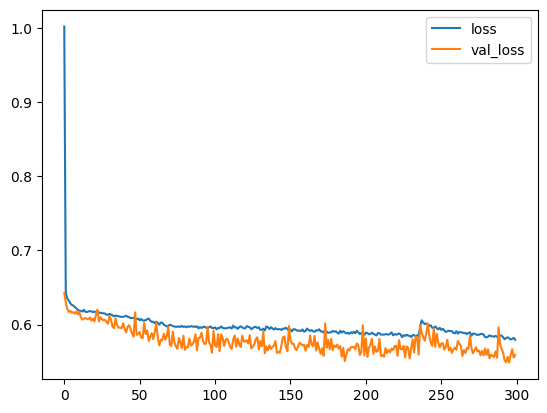

In [8]:
loss_df = pd.DataFrame(model.history.history)
loss_df[['loss', 'val_loss']].plot()

# The model learns in "bursts" rather than steadily (few drops), not overfitting
# there is room for improvement

<Axes: >

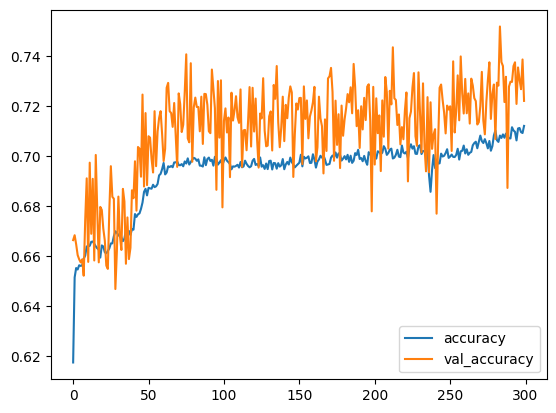

In [ ]:
# val_accuracy line is very noisy, but in general it is increasing, 
# the model learns but noise (so huge zigzags) is coming from somewhere.
# the accuracy blue line curve is pretty smooth,the model is learning but after about 0.685 it imroves slower, 
# but still there is a learning trend as both lines diapite huge zigzags of val_accuracygo upward. There is room for improvement definately.

loss_df[['accuracy', 'val_accuracy']].plot()

In [11]:
# compare the final model loss/accuracy/evaluation values
# the values should again match mostly
print("Test data evaluation:")
print(model.evaluate(X_test, y_test_encoded, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train_encoded, verbose=0))

Test data evaluation:
[0.5532151460647583, 0.7287612557411194]

Train data evaluation:
[0.5530908107757568, 0.7261551022529602]


In [13]:
# get predictions and convert with argmax() to get categories 
# instead of raw probabilities
test_predictions = model.predict(X_test)
test_predictions = np.argmax(test_predictions, axis=1)

# convert also y_test_encoded -values with argmax to get class indices
y_test_decoded = np.argmax(y_test_encoded, axis=1)

334/334 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step


<Axes: >

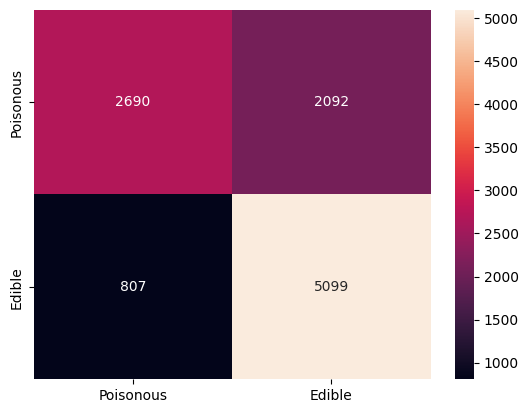

In [14]:
# Define categories
categories = ['Poisonous', 'Edible']

# confusion matrix
sns.heatmap(confusion_matrix(y_test_decoded, test_predictions), annot=True, fmt='g', 
            xticklabels=categories, yticklabels=categories)

In [16]:
# print the classification report based on true values and predictions
print(classification_report(y_test_decoded, test_predictions, target_names=categories))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test_decoded, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

   Poisonous       0.77      0.56      0.65      4782
      Edible       0.71      0.86      0.78      5906

    accuracy                           0.73     10688
   macro avg       0.74      0.71      0.71     10688
weighted avg       0.74      0.73      0.72     10688


Model overall accuracy: 72.88%


In [17]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary classification, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multi category classification , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# get ROC-AUC -score
roc_auc_score(y_test_decoded, test_predictions)

0.7129427176610337

### Test the model in practice with new data

In [18]:
X.columns

Index(['stem-width', 'stem-color_w', 'gill-spacing_d', 'gill-attachment_p',
       'stem-height'],
      dtype='object')

In [22]:
df.head(10)

,stem-width,stem-color_w,gill-spacing_d,gill-attachment_p,stem-height,class
0,17.09,1,0,0,16.95,1
1,18.19,1,0,0,17.99,1
2,17.74,1,0,0,17.80,1
3,15.98,1,0,0,15.77,1
4,17.20,1,0,0,16.53,1
5,18.79,1,0,0,17.84,1
6,16.89,1,0,0,17.71,1
7,17.44,1,0,0,17.03,1
8,18.69,1,0,0,17.27,1
9,16.88,1,0,0,16.04,1


In [ ]:
# let's try with some new imaginary data
# modify this as needed regarding your own dataset
tester_row = {
    'stem-width': 18.19,
    'stem-color_w': 1,
    'gill-spacing_d': 0,
    'gill-attachment_p': 0,
    'stem-height': 17.99
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])
result = model.predict(tester_row)[0]
result_text = categories[np.argmax(result)]

# switch to decimal representation 
np.set_printoptions(precision=9, suppress=True)

# Prediction output
# 0 - Poisonous, 1 - Edible
print(f"Predicted mushroom type: {result_text}")
print()
print("Probabilities by class:")
print(categories)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted mushroom type: Edible

Probabilities by class:
['Poisonous', 'Edible']
[0.3161004  0.68389964]


In [ ]:
# Trying to find out values to get edible mushroom prediction. 
# So, white stem and distant grill spacing is very common for poisonus mushrooms.
# let's try with some new imaginary data
# modify this as needed regarding your own dataset
tester_row = {
    'stem-width': 10.19,
    'stem-color_w': 1,
    'gill-spacing_d': 1,
    'gill-attachment_p': 0,
    'stem-height': 8.0
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])
result = model.predict(tester_row)[0]
result_text = categories[np.argmax(result)]

# switch to decimal representation 
np.set_printoptions(precision=9, suppress=True)

# Prediction output
# 0 - Poisonous, 1 - Edible
print(f"Predicted mushroom type: {result_text}")
print()
print("Probabilities by class:")
print(categories)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted mushroom type: Poisonous

Probabilities by class:
['Poisonous', 'Edible']
[0.7551641 0.2448359]


### Conclusion:

In the training model I used "categorical_crossentropy" loss function, it is perfect fit for classification ploblem. As optimazer I used adam. According to loss and val_loss grapths we could have stopped training on about 150 epochs without losing performance. <br
### Confusion matrix:
- out of 5906 edible mushroons, correctly identified were 5099 which is 86%. 
- out of 4782 poisonus mushrooms, correctly identified were just 2590 - 56%.
- The model is not good as it misses 44% of poisinus mushrooms.
### How well is the model works:
ROC_auc = 0.71 - poor result. This model is dangerous to use in real world especially with mushrooms))
**Recommendations for Future:**
1. Use early stopping at epoch about 150 to save training time
2. Analyse deeply poisonus mushroons
3. Maybe would be good to generate more poisonous mushroom data to make data more balanced
4. We used just 5 support variables in this model, should try tp use more of them.
5. Try ensemble methods (Random Forest, Gradient Boosting)
6. Use class weights to penalize False Positives more heavily
last two suggest by AI
